# Car Price Prediction - Student Test Notebook

This notebook is designed to help you practice data preprocessing, model training, and evaluation for predicting car prices.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
%matplotlib inline


In [2]:
# Load dataset
df = pd.read_csv("/content/car_price_predict_data.csv")
df.head()


,maker,model,mileage,manufacture_year,engine_displacement,engine_power,body_type,color_slug,stk_year,transmission,door_count,seat_count,fuel_type,date_created,date_last_seen,price_eur
0,toyota,yaris,31696.0,2011.0,1329.0,73.0,compact,grey,2016.0,man,3.0,5.0,gasoline,2016-01-06 19:25:07.416766+00,2016-01-17 13:19:36.517081+00,9490.0
1,nissan,note,9944.0,2014.0,1198.0,59.0,van,blue,2018.0,man,4.0,5.0,gasoline,2016-01-06 19:25:14.051308+00,2016-07-03 18:52:28.778609+00,10000.0
2,porsche,cayman,65000.0,2005.0,3386.0,217.0,coupe,silver,2016.0,man,2.0,2.0,gasoline,2016-01-06 19:25:26.075347+00,2016-07-03 18:41:05.832238+00,25800.0
3,opel,corsa,24348.0,2014.0,1229.0,63.0,compact,grey,2017.0,man,5.0,5.0,gasoline,2016-01-06 19:25:40.555298+00,2016-01-17 13:21:38.582038+00,9290.0
4,toyota,celica,155000.0,1999.0,1794.0,105.0,coupe,silver,2016.0,man,2.0,4.0,gasoline,2016-01-06 20:10:58.372777+00,2016-01-17 14:07:45.192729+00,3450.0


## Dataset Overview
Let's understand the structure of the data.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1607 entries, 0 to 1606
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   maker                1607 non-null   object 
 1   model                1607 non-null   object 
 2   mileage              1607 non-null   float64
 3   manufacture_year     1607 non-null   float64
 4   engine_displacement  1607 non-null   float64
 5   engine_power         1607 non-null   float64
 6   body_type            1607 non-null   object 
 7   color_slug           1607 non-null   object 
 8   stk_year             1607 non-null   float64
 9   transmission         1607 non-null   object 
 10  door_count           1607 non-null   float64
 11  seat_count           1607 non-null   float64
 12  fuel_type            1607 non-null   object 
 13  date_created         1607 non-null   object 
 14  date_last_seen       1607 non-null   object 
 15  price_eur            1607 non-null   f

In [4]:
df.describe(include='all')

,maker,model,mileage,manufacture_year,engine_displacement,engine_power,body_type,color_slug,stk_year,transmission,door_count,seat_count,fuel_type,date_created,date_last_seen,price_eur
count,1607,1607,1.607000e+03,1607.000000,1607.000000,1607.000000,1607,1607,1607.000000,1607,1607.000000,1607.000000,1607,1607,1607,1607.000000
unique,29,210,NaN,NaN,NaN,NaN,6,14,NaN,2,NaN,NaN,2,1607,1607,NaN
top,opel,corsa,NaN,NaN,NaN,NaN,compact,black,NaN,man,NaN,NaN,gasoline,2016-01-27 22:07:36.941713+00,2016-07-03 18:53:01.594607+00,NaN
freq,286,103,NaN,NaN,NaN,NaN,789,379,NaN,1351,NaN,NaN,1220,1,1,NaN
mean,NaN,NaN,1.194604e+05,2005.972620,1594.006223,79.105787,NaN,NaN,2016.790292,NaN,3.278158,4.568139,NaN,NaN,NaN,7891.598009
std,NaN,NaN,8.759467e+04,5.198117,610.350876,43.095350,NaN,NaN,0.803297,NaN,1.136583,1.261137,NaN,NaN,NaN,20403.607350
min,NaN,NaN,0.000000e+00,1966.000000,80.000000,25.000000,NaN,NaN,2016.000000,NaN,2.000000,2.000000,NaN,NaN,NaN,500.000000
25%,NaN,NaN,6.500400e+04,2003.000000,1242.000000,51.000000,NaN,NaN,2016.000000,NaN,2.000000,4.000000,NaN,NaN,NaN,2500.000000
50%,NaN,NaN,1.110000e+05,2006.000000,1490.000000,66.000000,NaN,NaN,2017.000000,NaN,4.000000,5.000000,NaN,NaN,NaN,4650.000000
75%,NaN,NaN,1.650000e+05,2010.000000,1798.000000,92.000000,NaN,NaN,2017.000000,NaN,4.000000,5.000000,NaN,NaN,NaN,8500.000000


## Exploratory Data Analysis (EDA)
We will visualize some key relationships in the dataset.

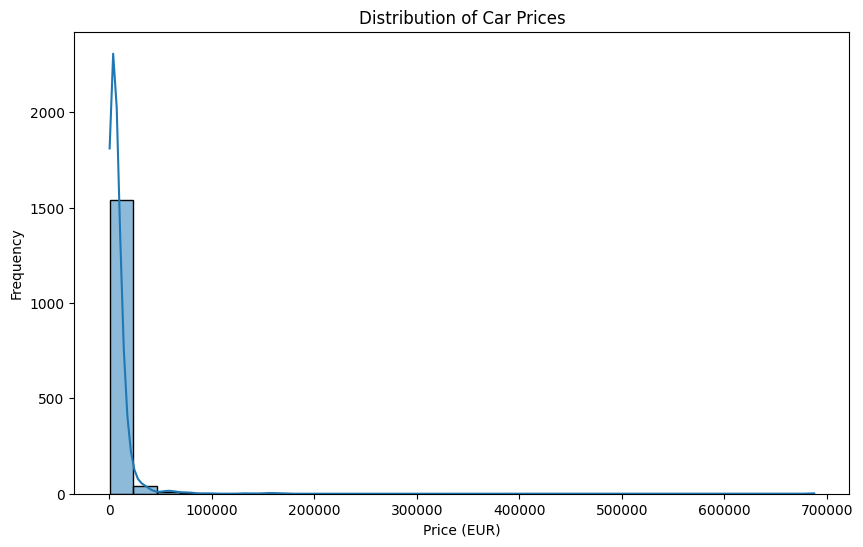

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price_eur'], bins=30, kde=True)
plt.title('Distribution of Car Prices')
plt.xlabel('Price (EUR)')
plt.ylabel('Frequency')
plt.show()


## Data Preprocessing
We'll clean and prepare the data for modeling.

In [6]:
# Drop non-numeric columns for a simple linear model
df_numeric = df.select_dtypes(include=[np.number])
# Drop rows with missing values
df_numeric = df_numeric.dropna()

## Train-Test Split

In [7]:
X = df_numeric.drop('price_eur', axis=1)
y = df_numeric['price_eur']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Model Training - Linear Regression

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

## Model Evaluation

In [9]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


MSE: 34805750.73255757
RMSE: 5899.639881599348
R2 Score: -0.0615923561636007


## 📚 Student Exercises
Try solving the following:

1. Add new features like `car_age = stk_year - manufacture_year` and see if it improves model performance.
2. Encode categorical variables like `fuel_type`, `body_type`, and `transmission` and try training a new model.
3. Try using a more complex model (e.g., RandomForestRegressor or GradientBoostingRegressor).
4. Plot a scatter plot of predicted vs actual prices to visualize model performance.


In [10]:
#Add new features like car_age = stk_year - manufacture_year and see if it improves model performance.
df['car_age'] = df['stk_year'] - df['manufacture_year']


In [11]:
#Encode categorical variables like fuel_type, body_type, and transmission and try training a new model.
df_encoded = pd.get_dummies(
    df,
    columns=['fuel_type', 'body_type', 'transmission'],
    drop_first=True
)


In [12]:
df_encoded = df_encoded.dropna()

In [13]:
X = df_encoded.drop('price_eur', axis=1)
y = df_encoded['price_eur']


In [14]:
#train-test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [15]:
#linear regression new
model_lr = LinearRegression()

X_train_numeric = X_train.select_dtypes(include=np.number)
X_test_numeric = X_test.select_dtypes(include=np.number)

model_lr.fit(X_train_numeric, y_train)

y_pred_lr = model_lr.predict(X_test_numeric)

print("Improved R2:", r2_score(y_test, y_pred_lr))

Improved R2: -0.06159235616359937


In [16]:
#Try using a more complex model (e.g., RandomForestRegressor or GradientBoostingRegressor).
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Select only numeric columns for training and prediction
X_train_numeric_rf = X_train.select_dtypes(include=np.number)
X_test_numeric_rf = X_test.select_dtypes(include=np.number)

rf_model.fit(X_train_numeric_rf, y_train)

y_pred_rf = rf_model.predict(X_test_numeric_rf)

print("Random Forest R²:", r2_score(y_test, y_pred_rf))

Random Forest R²: 0.5294753845625066


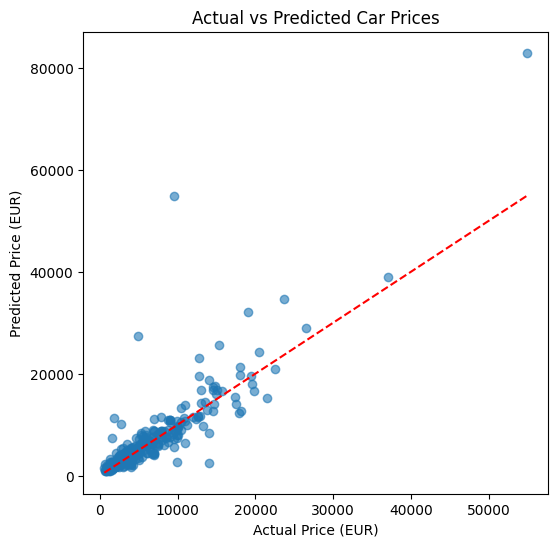

In [17]:
#Plot a scatter plot of predicted vs actual prices to visualize model performance.
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel("Actual Price (EUR)")
plt.ylabel("Predicted Price (EUR)")
plt.title("Actual vs Predicted Car Prices")
plt.show()
